#### Importing the necessary libraries and the data file

In [2]:
import numpy as np, pandas as pd
import matplotlib.pyplot as plt, seaborn as sns
%matplotlib inline
import warnings
warnings.filterwarnings('ignore')
from IPython.core.display import display, HTML
display(HTML("<style>.container {width:100% !important;}</style>"))

In [3]:
bank = pd.read_csv('bank.csv',sep = ';')

In [4]:
bank.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 41188 entries, 0 to 41187
Data columns (total 21 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   age             41188 non-null  int64  
 1   job             41188 non-null  object 
 2   marital         41188 non-null  object 
 3   education       41188 non-null  object 
 4   default         41188 non-null  object 
 5   housing         41188 non-null  object 
 6   loan            41188 non-null  object 
 7   contact         41188 non-null  object 
 8   month           41188 non-null  object 
 9   day_of_week     41188 non-null  object 
 10  duration        41188 non-null  int64  
 11  campaign        41188 non-null  int64  
 12  pdays           41188 non-null  int64  
 13  previous        41188 non-null  int64  
 14  poutcome        41188 non-null  object 
 15  emp.var.rate    41188 non-null  float64
 16  cons.price.idx  41188 non-null  float64
 17  cons.conf.idx   41188 non-null 

In [5]:
bank.head()

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,56,housemaid,married,basic.4y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
1,57,services,married,high.school,unknown,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
2,37,services,married,high.school,no,yes,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
3,40,admin.,married,basic.6y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
4,56,services,married,high.school,no,no,yes,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no


In [6]:
bank2 = bank.copy()

In [7]:
#Let's do the mapping for yes responses to 1's and nos to 0's
bank2.y = bank2.y.map({'yes':1,'no':0})

In [8]:
bank2.y.value_counts(normalize=True)

y
0    0.887346
1    0.112654
Name: proportion, dtype: float64

### Train-test split 

In [10]:
from sklearn.model_selection import train_test_split

In [11]:
df_train, df_test = train_test_split(bank2, random_state=42)

In [12]:
df_train.shape, df_test.shape

((30891, 21), (10297, 21))

## Working with the numerical variables

In [14]:
df_train.describe()

,age,duration,campaign,pdays,previous,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
count,30891.000000,30891.000000,30891.000000,30891.000000,30891.000000,30891.000000,30891.000000,30891.000000,30891.000000,30891.000000,30891.000000
mean,40.017287,257.551746,2.568839,963.029361,0.172348,0.083264,93.577223,-40.506782,3.622596,5167.037687,0.112881
std,10.448075,259.371218,2.747802,185.544213,0.492298,1.570746,0.579333,4.629842,1.734393,72.461175,0.316452
min,17.000000,0.000000,1.000000,0.000000,0.000000,-3.400000,92.201000,-50.800000,0.634000,4963.600000,0.000000
25%,32.000000,102.000000,1.000000,999.000000,0.000000,-1.800000,93.075000,-42.700000,1.344000,5099.100000,0.000000
50%,38.000000,179.000000,2.000000,999.000000,0.000000,1.100000,93.749000,-41.800000,4.857000,5191.000000,0.000000
75%,47.000000,318.000000,3.000000,999.000000,0.000000,1.400000,93.994000,-36.400000,4.961000,5228.100000,0.000000
max,98.000000,4918.000000,43.000000,999.000000,7.000000,1.400000,94.767000,-26.900000,5.045000,5228.100000,1.000000


`duration` feature

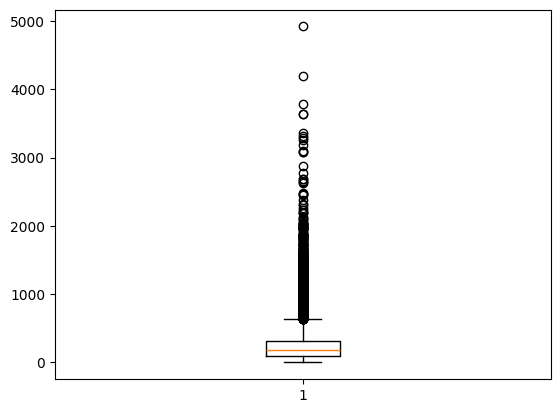

In [16]:
plt.boxplot(df_train.duration)
plt.show()

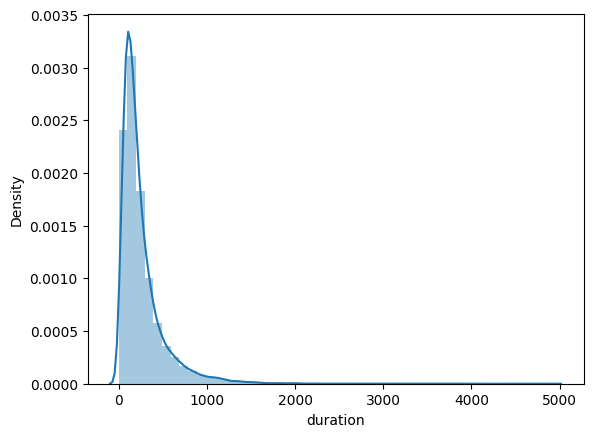

In [17]:
sns.distplot(df_train.duration)
plt.show()

#### Applying a log transformation 

In [19]:
df_train['dur_log'] = np.log1p(df_train.duration)

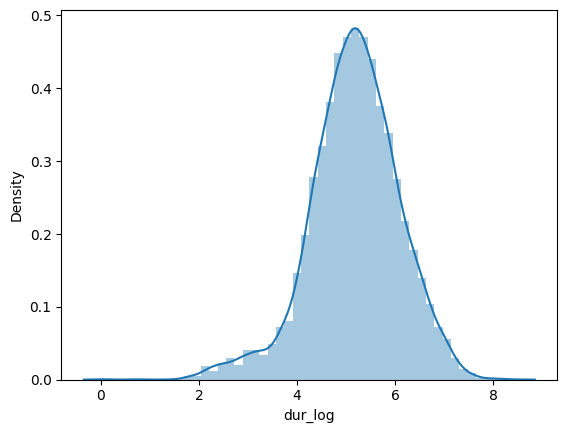

In [20]:
sns.distplot(df_train.dur_log)
plt.show()

### Applying PowerTransform 

In [22]:
from sklearn.preprocessing import PowerTransformer

In [23]:
pt = PowerTransformer()

In [24]:
df_train['dur_trans'] = pt.fit_transform(df_train[['duration']])

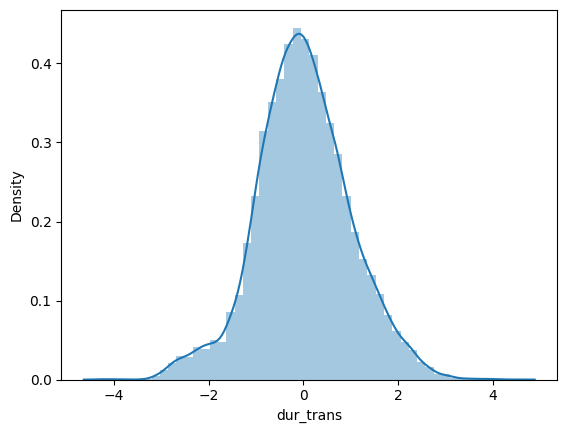

In [25]:
sns.distplot(df_train.dur_trans)
plt.show()

### Feature scaling

In [27]:
df_train[['age', 'dur_log']].describe()

,age,dur_log
count,30891.000000,30891.000000
mean,40.017287,5.170355
std,10.448075,0.916576
min,17.000000,0.000000
25%,32.000000,4.634729
50%,38.000000,5.192957
75%,47.000000,5.765191
max,98.000000,8.500861


In [28]:
from sklearn.preprocessing import MinMaxScaler

In [29]:
scaler = MinMaxScaler()

In [30]:
df_train[['dur_log']] = scaler.fit_transform(df_train[['dur_log']])

In [31]:
df_train[['dur_log']].describe()

,dur_log
count,30891.000000
mean,0.608215
std,0.107822
min,0.000000
25%,0.545207
50%,0.610874
75%,0.678189
max,1.000000


#### `age` variable

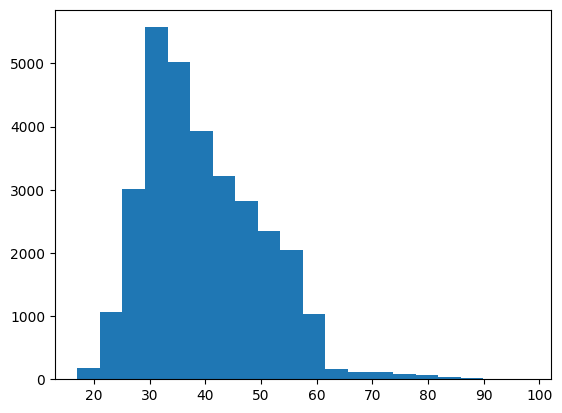

In [33]:
plt.hist(df_train.age, bins=20)
plt.show()

Create bins -   
 - < 25, 25-50, 50-75, >75

In [35]:
bin_manual = [0, 25, 50, 75, 100]
labs = ['<25', '25-50','50-75','above 75']

In [36]:
?pd.cut

Signature:
pd.cut(
    x,
    bins,
    right: 'bool' = True,
    labels=None,
    retbins: 'bool' = False,
    precision: 'int' = 3,
    include_lowest: 'bool' = False,
    duplicates: 'str' = 'raise',
    ordered: 'bool' = True,
)
Docstring:
Bin values into discrete intervals.

Use `cut` when you need to segment and sort data values into bins. This
function is also useful for going from a continuous variable to a
categorical variable. For example, `cut` could convert ages to groups of
age ranges. Supports binning into an equal number of bins, or a
pre-specified array of bins.

Parameters
----------
x : array-like
    The input array to be binned. Must be 1-dimensional.
bins : int, sequence of scalars, or IntervalIndex
    The criteria to bin by.

    * int : Defines the number of equal-width bins in the range of `x`. The
      range of `x` is extended by .1% on each side to include the minimum
      and maximum values of `x`.
    * sequence of scalars : Defines the bin edges allowing

In [37]:
df_train['age_bin'] = pd.cut(df_train.age, bins=bin_manual, labels=labs)

In [38]:
df_train[['age_bin','age']].head()

,age_bin,age
549,25-50,50
1974,25-50,26
20992,25-50,34
1730,25-50,30
26913,25-50,29


In [39]:
df_train.groupby('age_bin')['age'].agg(['max','min'])

,max,min
age_bin,,
<25,25,17
25-50,50,26
50-75,75,51
above 75,98,76


#### Quantile based binning

In [41]:
labs = ['VL','L','M','H','VH']
quantiles = [0, 0.2, 0.4, 0.6, 0.8, 1]

In [42]:
df_train['age_bin'] = pd.qcut(df_train.age, quantiles, labs)

In [43]:
df_train.groupby('age_bin')['age'].agg(['min', 'max'])

,min,max
age_bin,,
VL,17,31
L,32,35
M,36,41
H,42,49
VH,50,98


In [44]:
df_train.age_bin.value_counts(normalize=True)

age_bin
VL    0.227445
M     0.206597
VH    0.196336
H     0.195202
L     0.174420
Name: proportion, dtype: float64

## Categorical features

#### Dummy encoding

In [47]:
df_train.head()

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y,dur_log,dur_trans,age_bin
549,50,blue-collar,married,basic.4y,unknown,unknown,unknown,telephone,may,tue,...,nonexistent,1.1,93.994,-36.4,4.857,5191.0,0,0.592523,-0.203459,VH
1974,26,blue-collar,single,high.school,no,no,no,telephone,may,fri,...,nonexistent,1.1,93.994,-36.4,4.855,5191.0,0,0.631227,0.161299,VL
20992,34,technician,married,high.school,no,yes,no,cellular,aug,thu,...,nonexistent,1.4,93.444,-36.1,4.964,5228.1,0,0.523988,-0.813597,L
1730,30,blue-collar,single,basic.9y,no,yes,no,telephone,may,fri,...,nonexistent,1.1,93.994,-36.4,4.855,5191.0,0,0.679655,0.639368,VL
26913,29,admin.,single,university.degree,no,yes,no,cellular,nov,thu,...,nonexistent,-0.1,93.200,-42.0,4.076,5195.8,0,0.686379,0.707715,VL


In [48]:
df_train.marital.value_counts(normalize=True)

marital
married     0.602732
single      0.283189
divorced    0.112266
unknown     0.001813
Name: proportion, dtype: float64

In [49]:
pd.get_dummies(df_train.marital, prefix='Mari', drop_first=True)

,Mari_married,Mari_single,Mari_unknown
549,True,False,False
1974,False,True,False
20992,True,False,False
1730,False,True,False
26913,False,True,False
...,...,...,...
6265,True,False,False
11284,True,False,False
38158,True,False,False
860,True,False,False


In [50]:
pd.get_dummies(df_train, columns= ['marital'], prefix=['Mari',], drop_first=True)

,age,job,education,default,housing,loan,contact,month,day_of_week,duration,...,cons.conf.idx,euribor3m,nr.employed,y,dur_log,dur_trans,age_bin,Mari_married,Mari_single,Mari_unknown
549,50,blue-collar,basic.4y,unknown,unknown,unknown,telephone,may,tue,153,...,-36.4,4.857,5191.0,0,0.592523,-0.203459,VH,True,False,False
1974,26,blue-collar,high.school,no,no,no,telephone,may,fri,213,...,-36.4,4.855,5191.0,0,0.631227,0.161299,VL,False,True,False
20992,34,technician,high.school,no,yes,no,cellular,aug,thu,85,...,-36.1,4.964,5228.1,0,0.523988,-0.813597,L,True,False,False
1730,30,blue-collar,basic.9y,no,yes,no,telephone,may,fri,322,...,-36.4,4.855,5191.0,0,0.679655,0.639368,VL,False,True,False
26913,29,admin.,university.degree,no,yes,no,cellular,nov,thu,341,...,-42.0,4.076,5195.8,0,0.686379,0.707715,VL,False,True,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6265,58,retired,professional.course,unknown,no,no,telephone,may,tue,427,...,-36.4,4.857,5191.0,0,0.712766,0.980711,VH,True,False,False
11284,37,management,university.degree,no,no,no,telephone,jun,thu,288,...,-41.8,4.961,5228.1,0,0.666571,0.507765,M,True,False,False
38158,35,admin.,high.school,no,yes,no,cellular,oct,thu,194,...,-26.9,0.754,5017.5,1,0.620290,0.056697,L,True,False,False
860,40,management,university.degree,no,yes,no,telephone,may,wed,295,...,-36.4,4.856,5191.0,0,0.669386,0.535928,M,True,False,False


#### Job column

In [52]:
pd.get_dummies(df_train.job, prefix='job', drop_first=True)

,job_blue-collar,job_entrepreneur,job_housemaid,job_management,job_retired,job_self-employed,job_services,job_student,job_technician,job_unemployed,job_unknown
549,True,False,False,False,False,False,False,False,False,False,False
1974,True,False,False,False,False,False,False,False,False,False,False
20992,False,False,False,False,False,False,False,False,True,False,False
1730,True,False,False,False,False,False,False,False,False,False,False
26913,False,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...
6265,False,False,False,False,True,False,False,False,False,False,False
11284,False,False,False,True,False,False,False,False,False,False,False
38158,False,False,False,False,False,False,False,False,False,False,False
860,False,False,False,True,False,False,False,False,False,False,False


### Label encoding

In [54]:
from sklearn.preprocessing import LabelEncoder

In [55]:
lencoder = LabelEncoder()

In [56]:
?LabelEncoder

Init signature: LabelEncoder()
Docstring:     
Encode target labels with value between 0 and n_classes-1.

This transformer should be used to encode target values, *i.e.* `y`, and
not the input `X`.

Read more in the :ref:`User Guide <preprocessing_targets>`.

.. versionadded:: 0.12

Attributes
----------
classes_ : ndarray of shape (n_classes,)
    Holds the label for each class.

See Also
--------
OrdinalEncoder : Encode categorical features using an ordinal encoding
    scheme.
OneHotEncoder : Encode categorical features as a one-hot numeric array.

Examples
--------
`LabelEncoder` can be used to normalize labels.

>>> from sklearn import preprocessing
>>> le = preprocessing.LabelEncoder()
>>> le.fit([1, 2, 2, 6])
LabelEncoder()
>>> le.classes_
array([1, 2, 6])
>>> le.transform([1, 1, 2, 6])
array([0, 0, 1, 2]...)
>>> le.inverse_transform([0, 0, 1, 2])
array([1, 1, 2, 6])

It can also be used to transform non-numerical labels (as long as they are
hashable and comparable) to numerica

In [134]:
df_train.job.value_counts()

job
admin.           7845
blue-collar      6975
technician       4989
services         3006
management       2167
retired          1277
self-employed    1079
entrepreneur     1075
housemaid         804
unemployed        745
student           679
unknown           250
Name: count, dtype: int64

In [57]:
df_train['job_le'] = lencoder.fit_transform(df_train.job)

In [58]:
df_train.groupby('job')['job_le'].agg(['min', 'max'])

,min,max
job,,
admin.,0,0
blue-collar,1,1
entrepreneur,2,2
housemaid,3,3
management,4,4
retired,5,5
self-employed,6,6
services,7,7
student,8,8


### Mean encoding

In [60]:
map_mean = df_train.groupby('job')['y'].mean()
map_mean

job
admin.           0.131931
blue-collar      0.069964
entrepreneur     0.082791
housemaid        0.088308
management       0.109829
retired          0.245106
self-employed    0.099166
services         0.083832
student          0.307806
technician       0.110643
unemployed       0.144966
unknown          0.100000
Name: y, dtype: float64

In [61]:
df_train['job_mean_encode'] = df_train.job.map(map_mean)

In [62]:
df_train.groupby('job')['job_mean_encode'].agg(['min', 'max'])

,min,max
job,,
admin.,0.131931,0.131931
blue-collar,0.069964,0.069964
entrepreneur,0.082791,0.082791
housemaid,0.088308,0.088308
management,0.109829,0.109829
retired,0.245106,0.245106
self-employed,0.099166,0.099166
services,0.083832,0.083832
student,0.307806,0.307806


### Clubbing categories

#### Top N based on frequency

In [65]:
df_train.job.value_counts(normalize=True)

job
admin.           0.253957
blue-collar      0.225794
technician       0.161503
services         0.097310
management       0.070150
retired          0.041339
self-employed    0.034929
entrepreneur     0.034800
housemaid        0.026027
unemployed       0.024117
student          0.021981
unknown          0.008093
Name: proportion, dtype: float64

In [66]:
job_freqs = df_train.job.value_counts(normalize=True)

In [67]:
job_freqs.cumsum()

job
admin.           0.253957
blue-collar      0.479751
technician       0.641255
services         0.738565
management       0.808715
retired          0.850053
self-employed    0.884983
entrepreneur     0.919782
housemaid        0.945809
unemployed       0.969927
student          0.991907
unknown          1.000000
Name: proportion, dtype: float64

In [68]:
top_jobs = job_freqs.cumsum()[:4].index
top_jobs

Index(['admin.', 'blue-collar', 'technician', 'services'], dtype='object', name='job')

In [69]:
df_train['job_mod_topn'] = np.where(df_train.job.isin(top_jobs), df_train.job, 'OTH')

In [70]:
df_train.groupby(['job_mod_topn','job']).size()

job_mod_topn  job          
OTH           entrepreneur     1075
              housemaid         804
              management       2167
              retired          1277
              self-employed    1079
              student           679
              unemployed        745
              unknown           250
admin.        admin.           7845
blue-collar   blue-collar      6975
services      services         3006
technician    technician       4989
dtype: int64

### Clubbing categories - based on Target

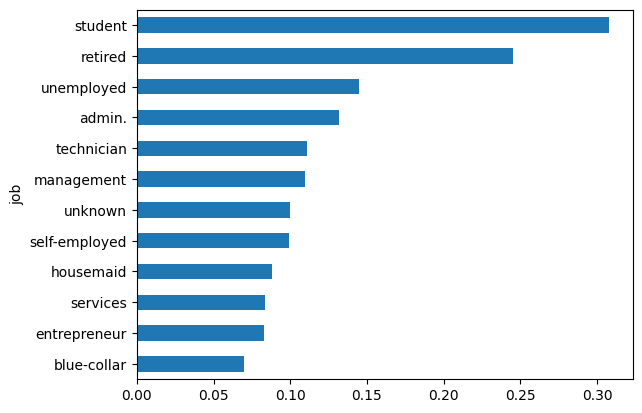

In [72]:
df_train.groupby('job')['y'].mean().sort_values().plot.barh()
plt.show()

In [73]:
def club_on_y(val):
    if val in ['student','retired']:
        return 'a_high'
    elif val in ['services', 'entrepreneur','blue-collar']:
        return 'c_low'
    else:
        return 'b_med'

In [74]:
df_train['job_mod_tgt'] = df_train.job.apply(club_on_y)

In [75]:
df_train.groupby(['job_mod_tgt','job']).size()

job_mod_tgt  job          
a_high       retired          1277
             student           679
b_med        admin.           7845
             housemaid         804
             management       2167
             self-employed    1079
             technician       4989
             unemployed        745
             unknown           250
c_low        blue-collar      6975
             entrepreneur     1075
             services         3006
dtype: int64